<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy y epsilon-decaimiento en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/06


## Preparación del entorno


In [21]:
#@title Copiar el repositorio.

#git clone https://github.com/ldaniel-hm/eml_k_bandit.git
#!cd eml_k_bandit/

In [22]:
#@title Importamos todas las clases y funciones

#import sys

# Añadir los directorio fuentes al path de Python
#sys.path.append('/content/eml_k_bandit')


# Verificar que se han añadido correctamente
#print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecaimiento

from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret


## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos en términos de recompensa promedio.

Por ejemplo. Dado un bandido de k-brazos, se ejecutan tres algoritmos $\epsilon$-greedy con diferentes valores de $\epsilon$ y un algoritmo $\epsilon$-decaimiento. Se estudia la evolución de cada política  en un número de pasos, por ejemplo, mil pasos. Entonces se repite el experimento un número de veces, por ejemplo, 500 veces. Es decir, se ejecutan 500 veces la evolución de cada algoritmo en 1000 pasos. Para cada paso calculamos el promedio de las recompensas obtenidas en esas 500 veces.

In [23]:
from utils import run_experiment

## Ejecución del experimento

Se realizan tres experimentos, variando en cada uno de ellos la distribución de probabilidad de las recompensas asociadas a cada brazo. En el primer experimento, cada brazo sigue una distribución normal con media $\mu\in[1,10]$ y desviación típica $\sigma=1$. En el segundo experimento, cada brazo sigue una distribución de Bernoulli con parámetro $p\in[0.1,1]$, escalada por un factor 10 para hacer comparables las recompensas. En el tercer experimento, cada brazo sigue una distribución binomial con $n=10$, y $p\in[0.1,1]$.

En todos los casos se utiliza un bandido de 10 brazos. Se realizan 500 ejecuciones de 1000 pasos cada una. Para cada experimento se realizan 500 ejecuciones, cada una de 1000 pasos de tiempo. Se comparan tres algoritmos $\epsilon$-greedy para valores $\epsilon$: 0.0, 0.01, y 0.1, y un algoritmo $\epsilon$-decaimiento con epsilon inicial $\epsilon_0=1.0$, tasa de decaimiento $\lambda_{decay}=0.01$, y epsilon mínimo $\epsilon_{min}=0.01$. En el caso del $\epsilon$-decaimiento no se permite que $\epsilon$ llegue a cero, ya que se desea mantener un nivel mínimo de exploración para evitar caer en óptimos locales, siguiendo la recomendación del profesor.

In [24]:
import json

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

### Experimento 1: Distribución normal

In [25]:
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)  # Imprimir la configuración del bandido

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon y un algoritmo epsilon-decaimiento.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), EpsilonDecaimiento(k=k, epsilon_0=1.0, lambda_decay=0.01, epsilon_min=0.01), ]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


En este experimento se genera un bandido de 10 brazos, cada uno con una distribución normal de media entre 1 y 10 y desviación típica 1. En esta instancia concreta, el brazo 8 resulta ser el óptimo, con una recompensa esperada de 9.56.

#### Visualización de los resultados

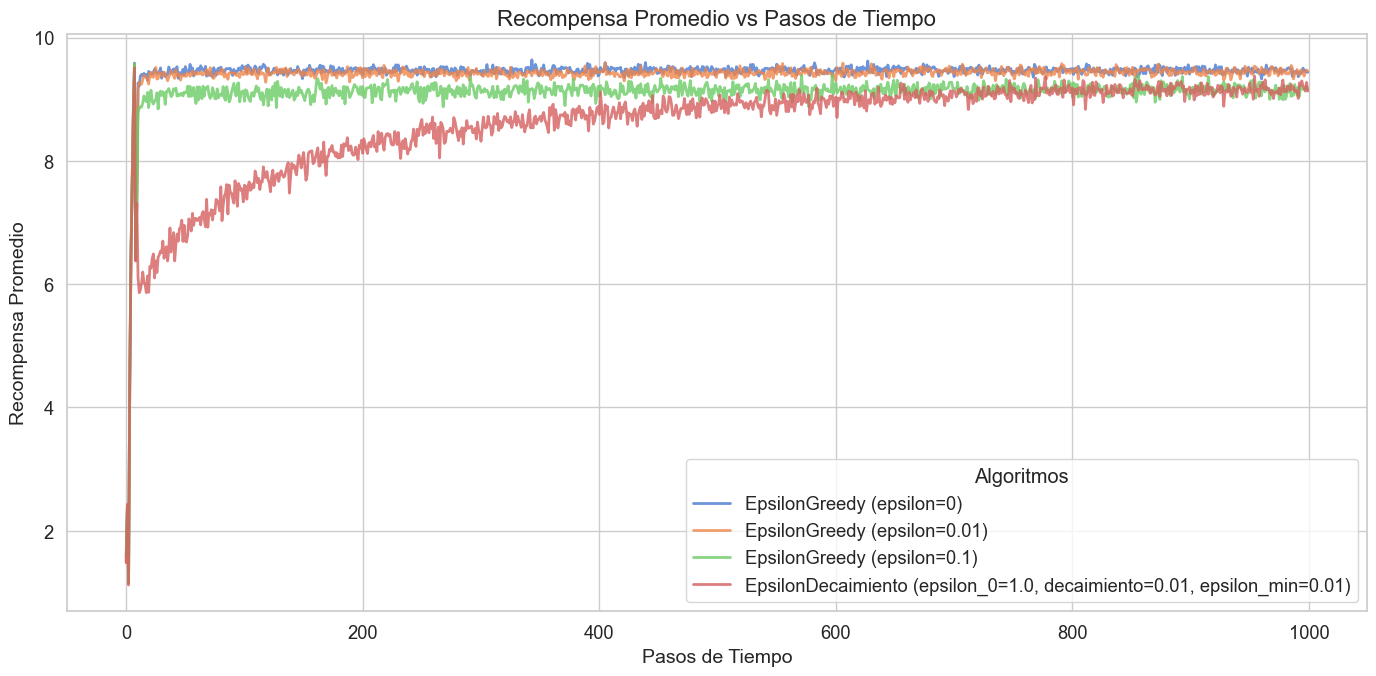

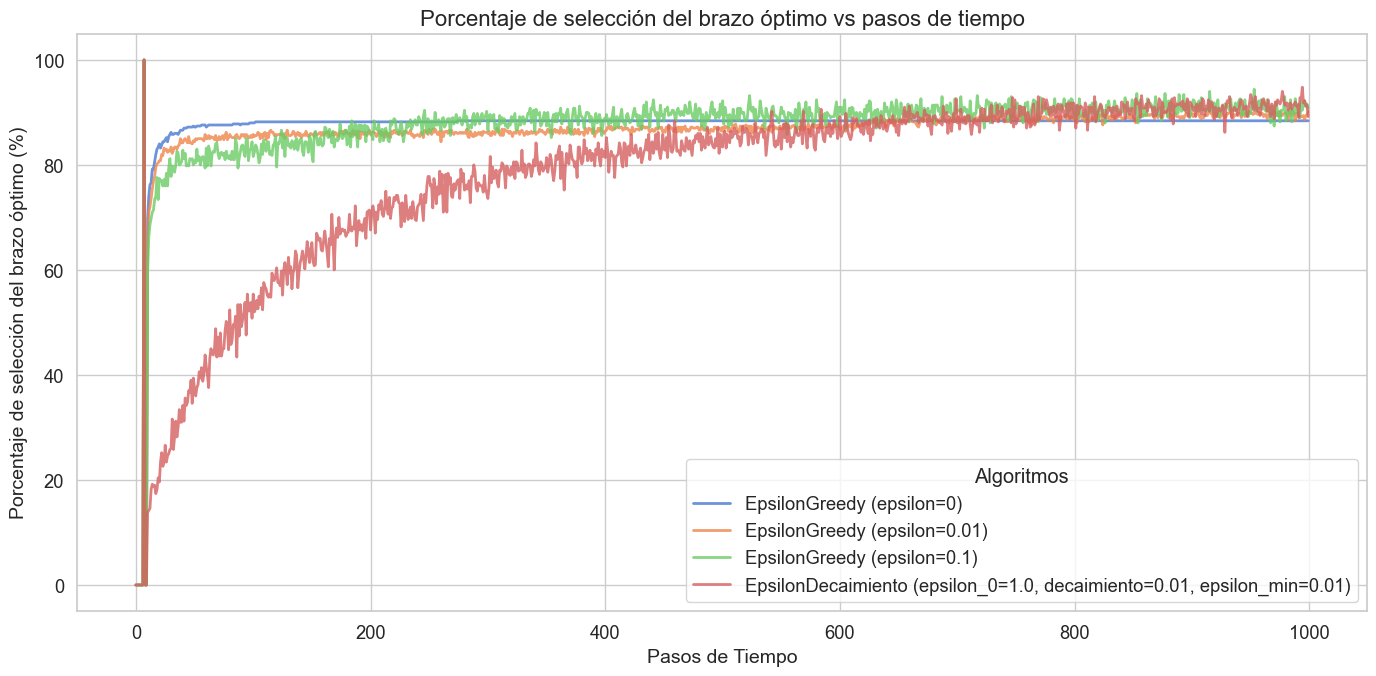

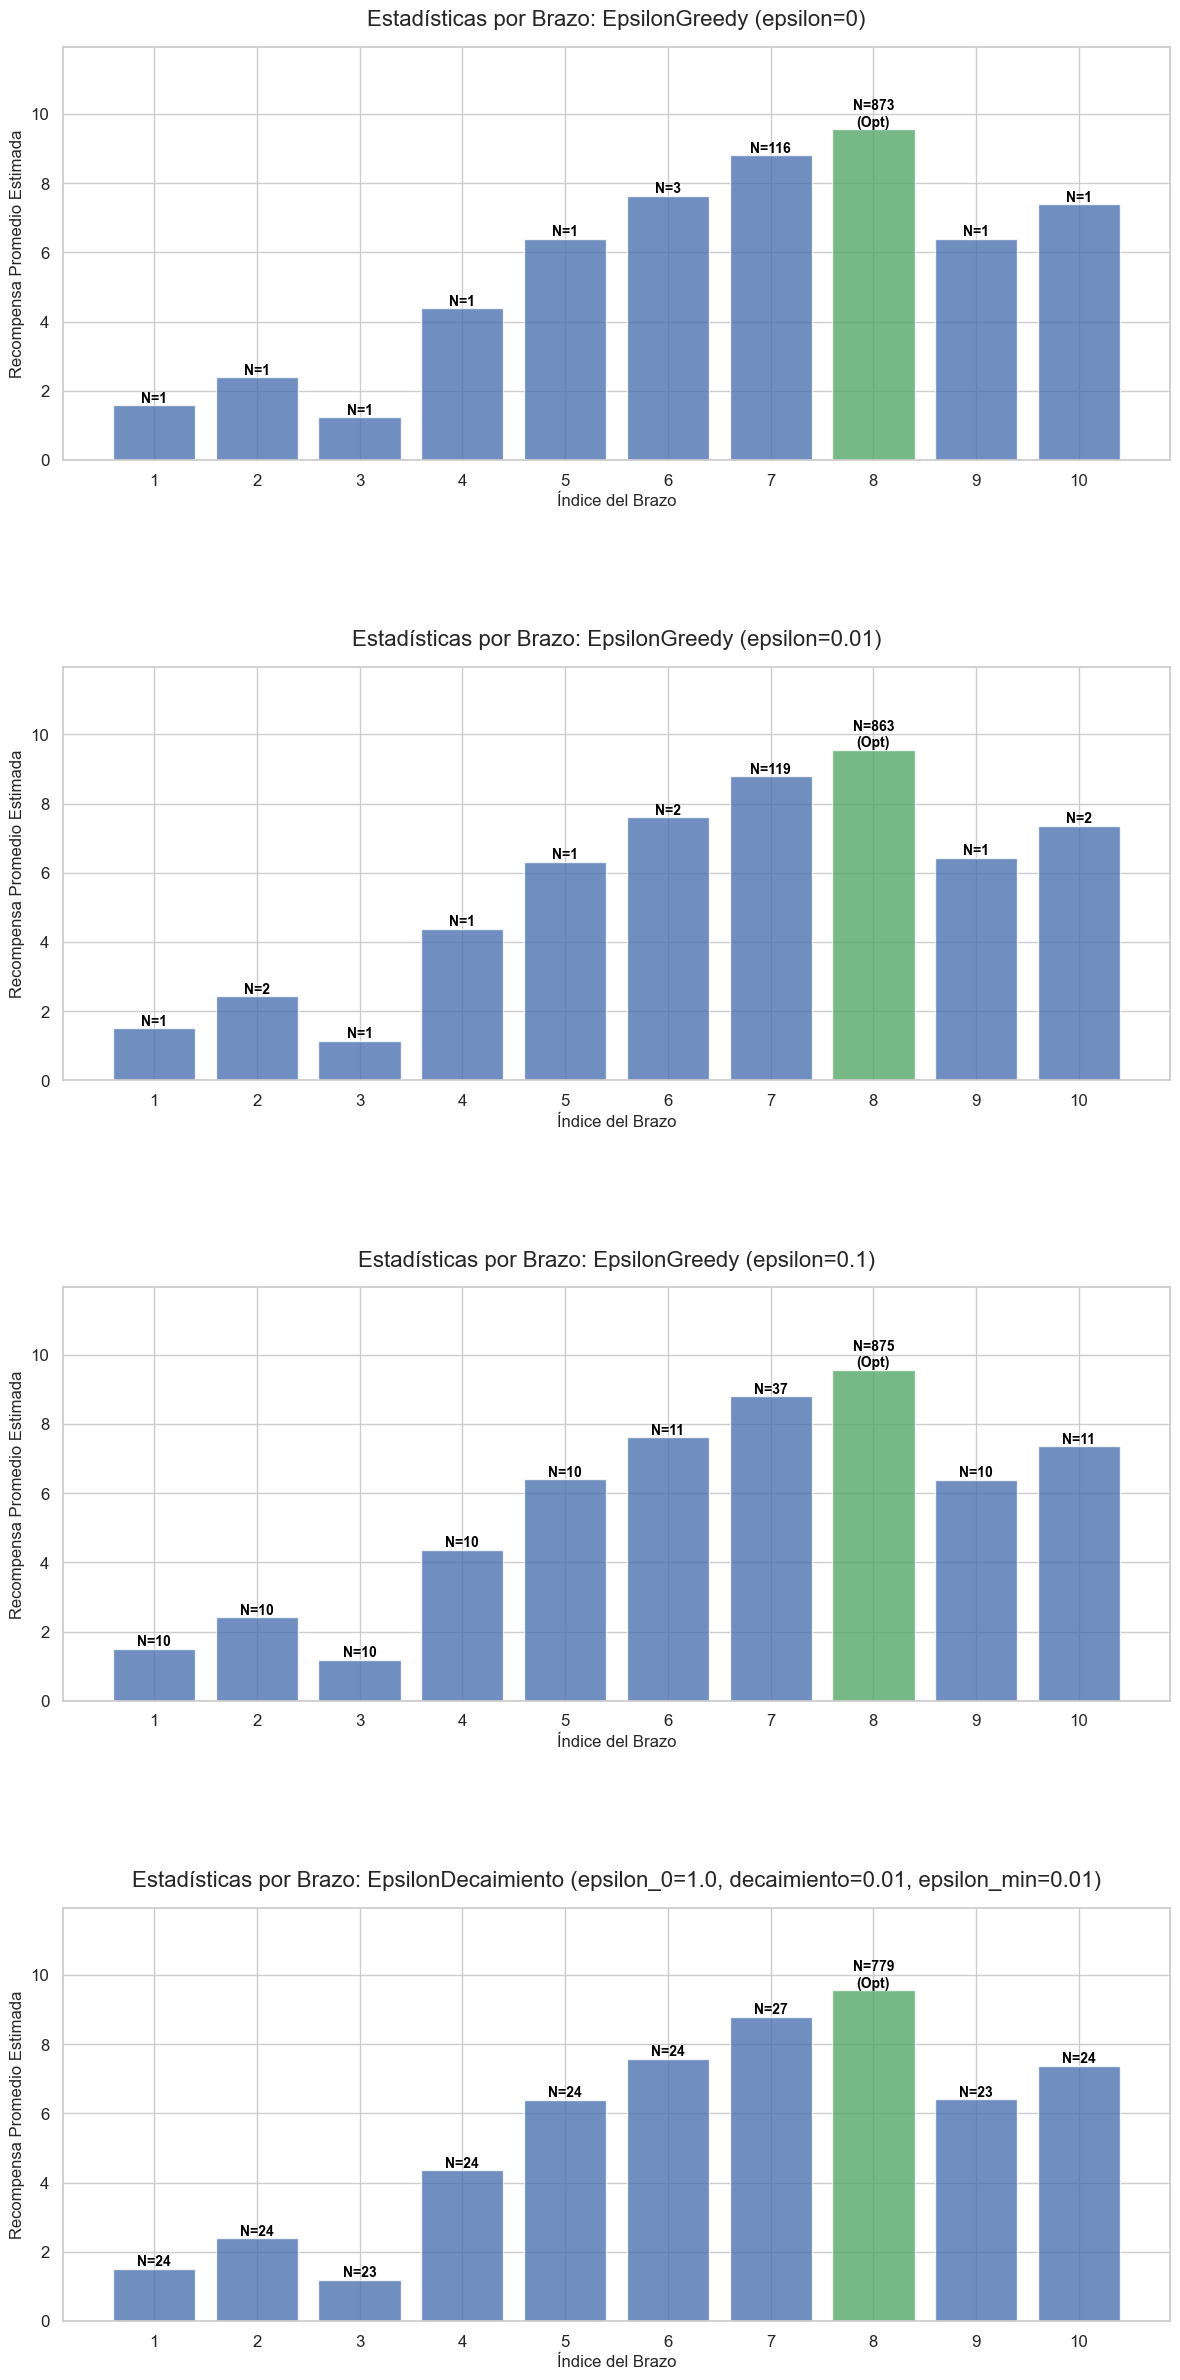

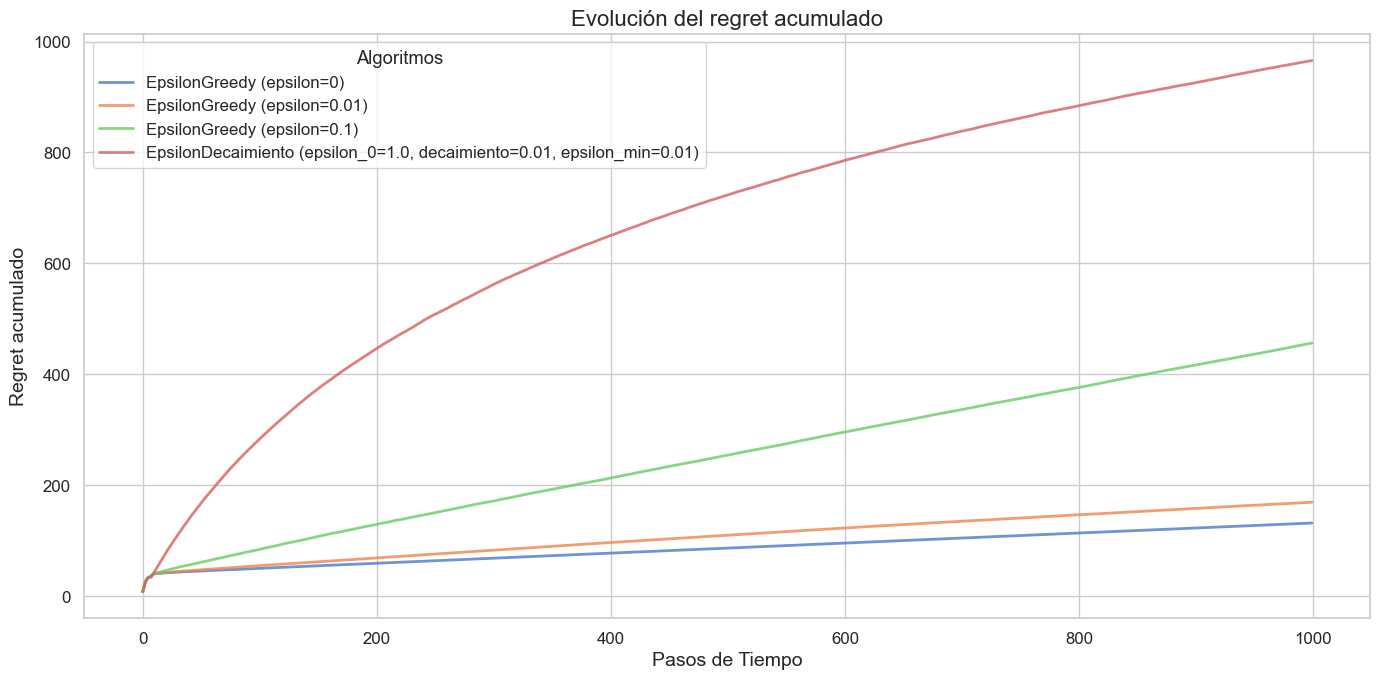

In [26]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis detallado de la imagen

En todas las gráficas de líneas aparecen **cuatro curvas de colores distintos que representan tres valores diferentes de $\epsilon$ en el algoritmo $\epsilon$-Greedy, y una para el algoritmo $\epsilon$-decaimiento:**
   - **Azul ($\epsilon$ = 0):** Representa una estrategia completamente **explotadora**, es decir, que siempre elige la acción que ha dado la mejor recompensa hasta ahora sin explorar nuevas opciones.
   - **Naranja ($\epsilon$ = 0.01):** Representa una estrategia con una pequeña probabilidad del 1% de elegir una acción aleatoria (exploración).
   - **Verde ($\epsilon$ = 0.1):** Representa una estrategia con un 10% de probabilidad de explorar acciones aleatorias
   - **Rojo ($\epsilon$-decaimiento):** Representa una estrategia que comienza con una alta probabilidad de exploración ($\epsilon_0=1.0$) y la va reduciendo gradualmente ($\lambda_{decay} = 0.01$) a medida que avanza el tiempo, hasta un mínimo de $\epsilon_{min}=0.01$.


#### Recompensa promedio vs pasos de tiempo

La primera imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se analiza el desempeño de diferentes estrategias del algoritmo **$\epsilon$-Greedy** en un entorno de multi-armed bandit. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra la **recompensa promedio** obtenida por cada algoritmo.

   - La línea **azul ($\epsilon$=0)** mantiene su recompensa promedio en un nivel alto. Esto se debe a que, antes de comenzar la explotación, el algoritmo realiza un recorrido inicial por todos los brazos para obtener estimaciones iniciales de sus recompensas. Gracias a ello, en la mayoría de las ejecuciones identifica rápidamente el brazo óptimo y lo explota durante el resto del tiempo. No obstante, este comportamiento depende fuertemente de de la estimación inicial.
   - La línea **naranja ($\epsilon$=0.01)** muestra un crecimiento de la recompensa promedio, pero más lento que para $\epsilon$=0.1, debido a su menor exploración.
   - La línea **verde ($\epsilon$=0.1)** alcanza rápidamente una recompensa promedio alta, lo que indica que la estrategia con mayor exploración aprende más rápido qué brazos del bandit son óptimos. Sin embargo, a largo plazo la recompensa promedio no puede superar aproximadamente el 90% del óptimo, ya que existe una probabilidad constante del 10% de seleccionar brazos subóptimos.
   - La línea **roja ($\epsilon$-decaimiento)** presenta un crecimiento inicial lento debido a su alta probabilidad de exploración al inicio. A medida que la probabilidad de exploración $\epsilon$ disminuye según la función de decaimiento inversamente proporcional $f(t,\epsilon_0,\lambda)=\frac{\epsilon_0}{1+\lambda t}$, la recompensa promedio se estabiliza en un nivel alto pues el algoritmo comienza a explotar más las opciones que han demostrado ser mejores, superando incluso a la estrategia con $\epsilon$=0.1 a largo plazo, ya que esta última sigue explorando con una probabilidad constante del 10% mientras que el $\epsilon$-decaimiento se queda con una probabilidad del 1%.
   
   Al final del proceso, todos los algoritmos convergen hacia la recompensa esperada del brazo óptimo (9.56), lo que indica que acaban identificándolo.
   
   En definitiva, con un número de pasos suficientemente grandes, los algoritmos de $\epsilon$-greedy con $\epsilon$=0.01 y $\epsilon$-decaimiento deberían coincidir, siendo los que mejor recompensas proporcionan. Dependiendo de la ejecución concreta, podría superar a $\epsilon$=0 o quedarse por debajo muy cerca de él. El que más rápido crece es $\epsilon$=0.1, pero a largo plazo se queda por debajo de los otros debido a su probabilidad de exploración del 10%.

#### Porcentaje de selección del brazo óptimo

La segunda gráfica, titulada **"Porcentaje de selección del brazo óptimo vs pasos de tiempo"**, se muestra un gráfico de líneas similar al anterior pero en este caso el eje **y** representa el **porcentaje de selección del brazo óptimo** a lo largo del tiempo. Este gráfico nos permite analizar cómo cada estrategia mejora su capacidad para identificar y seleccionar el brazo óptimo a medida que avanza el tiempo (como en todas las gráficas, promediado sobre las 500 runs). Aquí se observa claramente el efecto de $\epsilon$:

- $\epsilon$=0.1 aprende rápidamente cuál es el brazo óptimo, pero no puede superar el 90% de selección del brazo óptimo debido a su constante probabilidad de exploración. 
- $\epsilon$-decaimiento, que reduce su probabilidad de exploración con el tiempo, logra superar ese límite y acercarse al 100% de selección del brazo óptimo a largo plazo.
- $\epsilon$=0.01 muestra un comportamiento similar, aunque con una exploración menor. 
- $\epsilon$=0 depende completamente de la estimación inicial: si esta es correcta, puede alcanzar el 100% de selección casi inmediatamente; si es errónea, queda atrapado en una mala elección durante toda la ejecución. 

#### Estadísticas por brazo 

Lo anterior se ve reforzado por el gráfico **"Estadísticas por brazo"**, que muestra un histograma donde, para cada brazo, se representa el número de veces que ha sido seleccionado a lo largo de los 1000 pasos de tiempo (promediado sobre las 500 ejecuciones), y en el eje **y** la recompensa promedio obtenida por dicho brazo, la cual se aproxima a su valor esperado.

En el caso del algoritmo con $\epsilon = 0$, se observa que aproximadamente el 87% de las ejecuciones logran identificar el brazo óptimo desde el inicio, mientras que el 13% restante queda atrapado en una elección subóptima y no llega a identificar el brazo óptimo en ningún momento. Dado que, dentro de una misma ejecución, una vez que el algoritmo explotador selecciona un brazo continúa eligiéndolo de forma determinista, el histograma refleja directamente esta proporción: el brazo óptimo es seleccionado el 87.3% de las veces y el resto de los brazos concentra el 13% restante.

En los demás algoritmos, la exploración juega un papel más relevante dentro de cada ejecución, por lo que el histograma refleja la tasa de selección asociada a cada valor de $\epsilon$. En particular, el algoritmo con $\epsilon = 0.1$ y $\epsilon = 0.01$ son similares al de $\epsilon = 0$, pero en este caso debido a la estimación inicial, aunque para un número de pasos suficientemente grande deberían tender al 90% y 99%, respectivamente. Por otro lado,el algoritmo $\epsilon$-decaimiento presenta el peor resultado medio, debido a su elevada tasa de exploración inicial, que reduce su frecuencia de selección del brazo óptimo y, en consecuencia, su recompensa promedio.

#### Regret acumulado

La última gráfica, **"Evolución del regret acumulado"**, muestra un gráfico de líneas en el que se representa la evolución del regret acumulado a lo largo del tiempo para cada algoritmo. El regret acumulado se calcula como la diferencia entre la recompensa que se habría obtenido si siempre se hubiera elegido el brazo óptimo y la recompensa realmente obtenida por el algoritmo (la recompensa esperada del brazo seleccionado). 

Inicialmente, el regret crece más rápido para los algoritmos con mayor exploración ($\epsilon$ = 0.1 y $\epsilon$-decaimiento). Sin embargo, a largo plazo, el crecimiento del regret se estabiliza para todos los algoritmos, indicando que todos logran identificar el brazo óptimo. No obstante, no llegan a ser del todo estables porque en los algoritmos con $\epsilon$ distinto de cero, el regret sigue aumentando lentamente debido al porcentaje exploración.

---

#### Notas

   - Durante los 10 primeros pasos, todos los algoritmos muestran un comportamiento prácticamente idéntico, ya que se fuerza un recorrido inicial por todos los brazos para obtener estimaciones iniciales de sus recompensas. Esto hace que en esos primeros pasos se elija cada brazo una vez, y por tanto, se obtenga la misma recompensa promedio para todos los algoritmos.
   - El buen desempeño de $\epsilon$=0 se debe a que separa claramente la exploración inicial de la explotación posterior. En general, resulta mejor realizar primero la exploración y luego la explotación, ya que mezclar ambas fases puede llevar a que el algoritmo quede atascado en una mala estimación de las recompensas durante varios steps, lo que empeora la recompensa obtenida. En cambio, si se hace primero toda la exploración, el algoritmo obtiene una buena estimación de las recompensas de cada brazo desde el principio, lo que le permite centrarse en el brazo óptimo durante el resto del tiempo y obtener una recompensa promedio alta.





### Experimento 2: Distribución de Bernoulli

In [29]:
# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k,scale=10)) # Generar un bandido con k brazos de distribución normal
print(bandit)  # Imprimir la configuración del bandido

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon y un algoritmo epsilon-decaimiento.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), EpsilonDecaimiento(k=k, epsilon_0=1.0, lambda_decay=0.01, epsilon_min=0.01), ]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmBernoulli(p=0.97), ArmBernoulli(p=0.23), ArmBernoulli(p=0.10), ArmBernoulli(p=0.30), ArmBernoulli(p=0.93), ArmBernoulli(p=0.15), ArmBernoulli(p=0.44), ArmBernoulli(p=0.92), ArmBernoulli(p=0.22), ArmBernoulli(p=0.54)
Optimal arm: 1 with expected reward=9.661999999999999


Al cambiar la distribución de recompensas de cada brazo a una distribución de Bernoulli con $p\in[0.1, 1.0]$, y aplicar un factor de escalado de 10, el brazo 1 resulta ser el óptimo, con una recompensa esperada de 9.66.

#### Visualización de los resultados

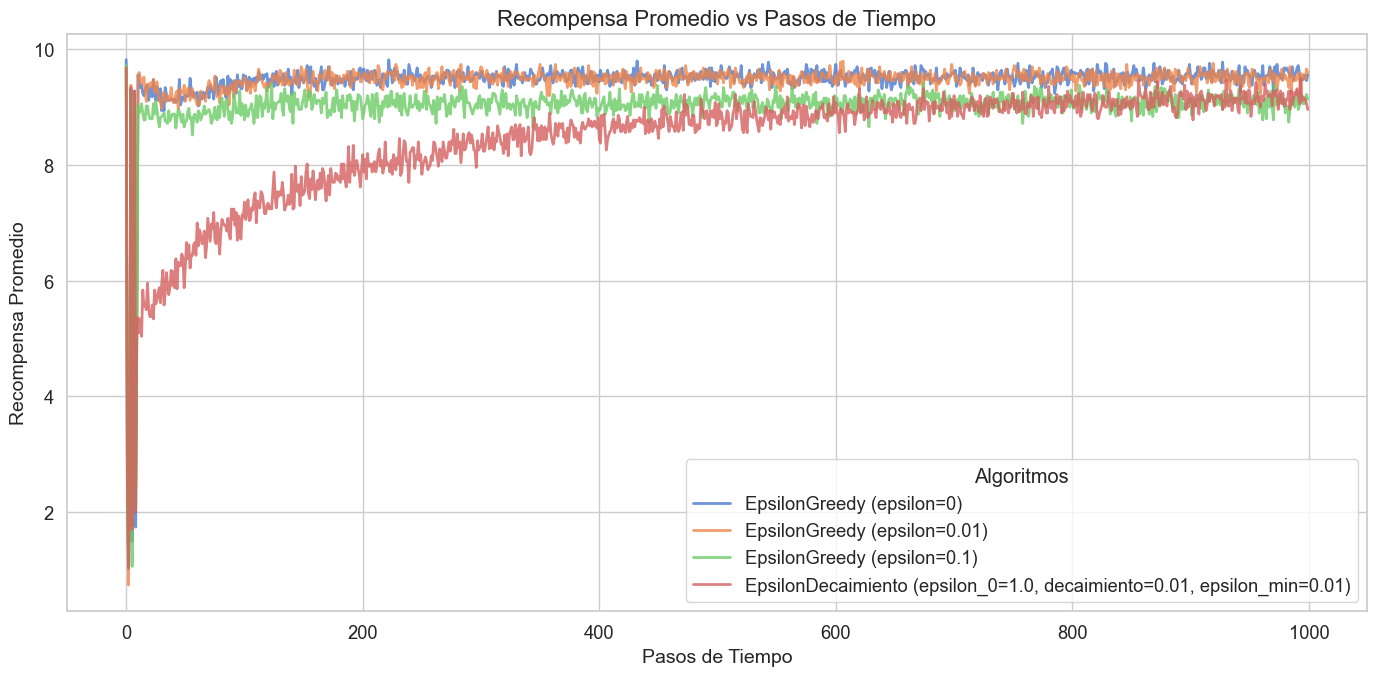

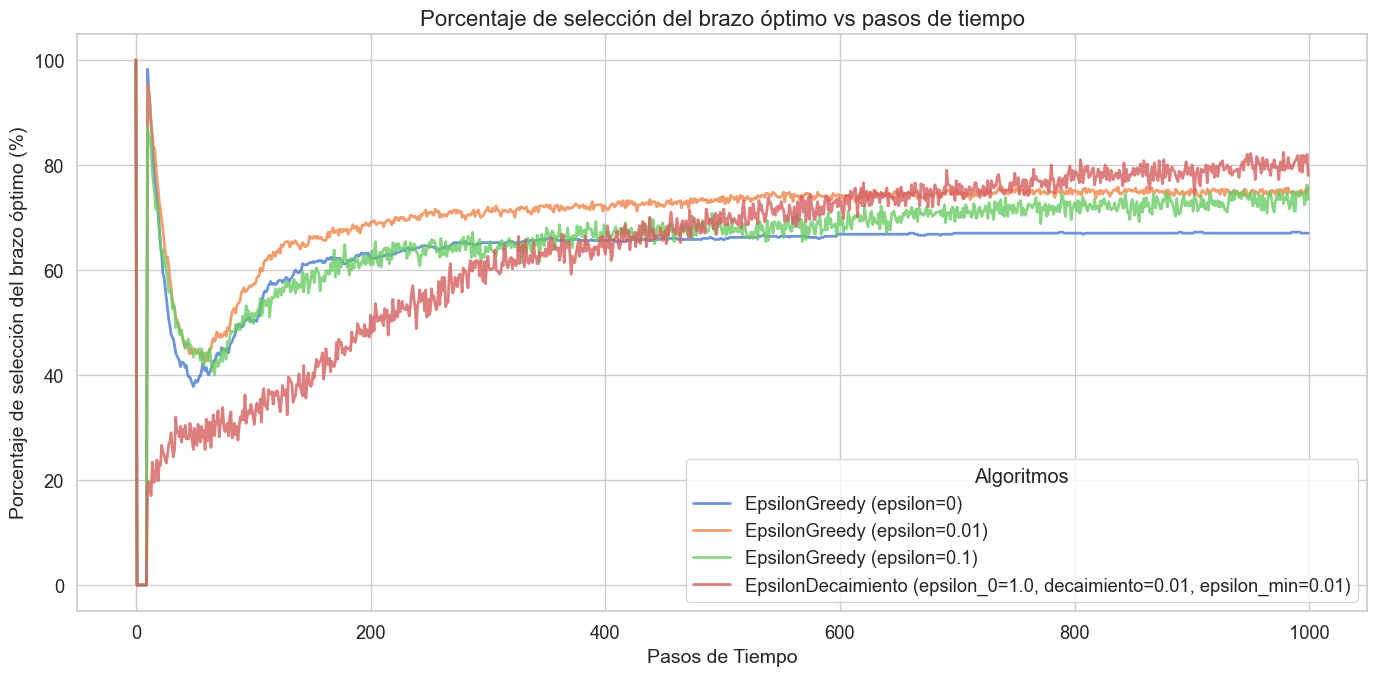

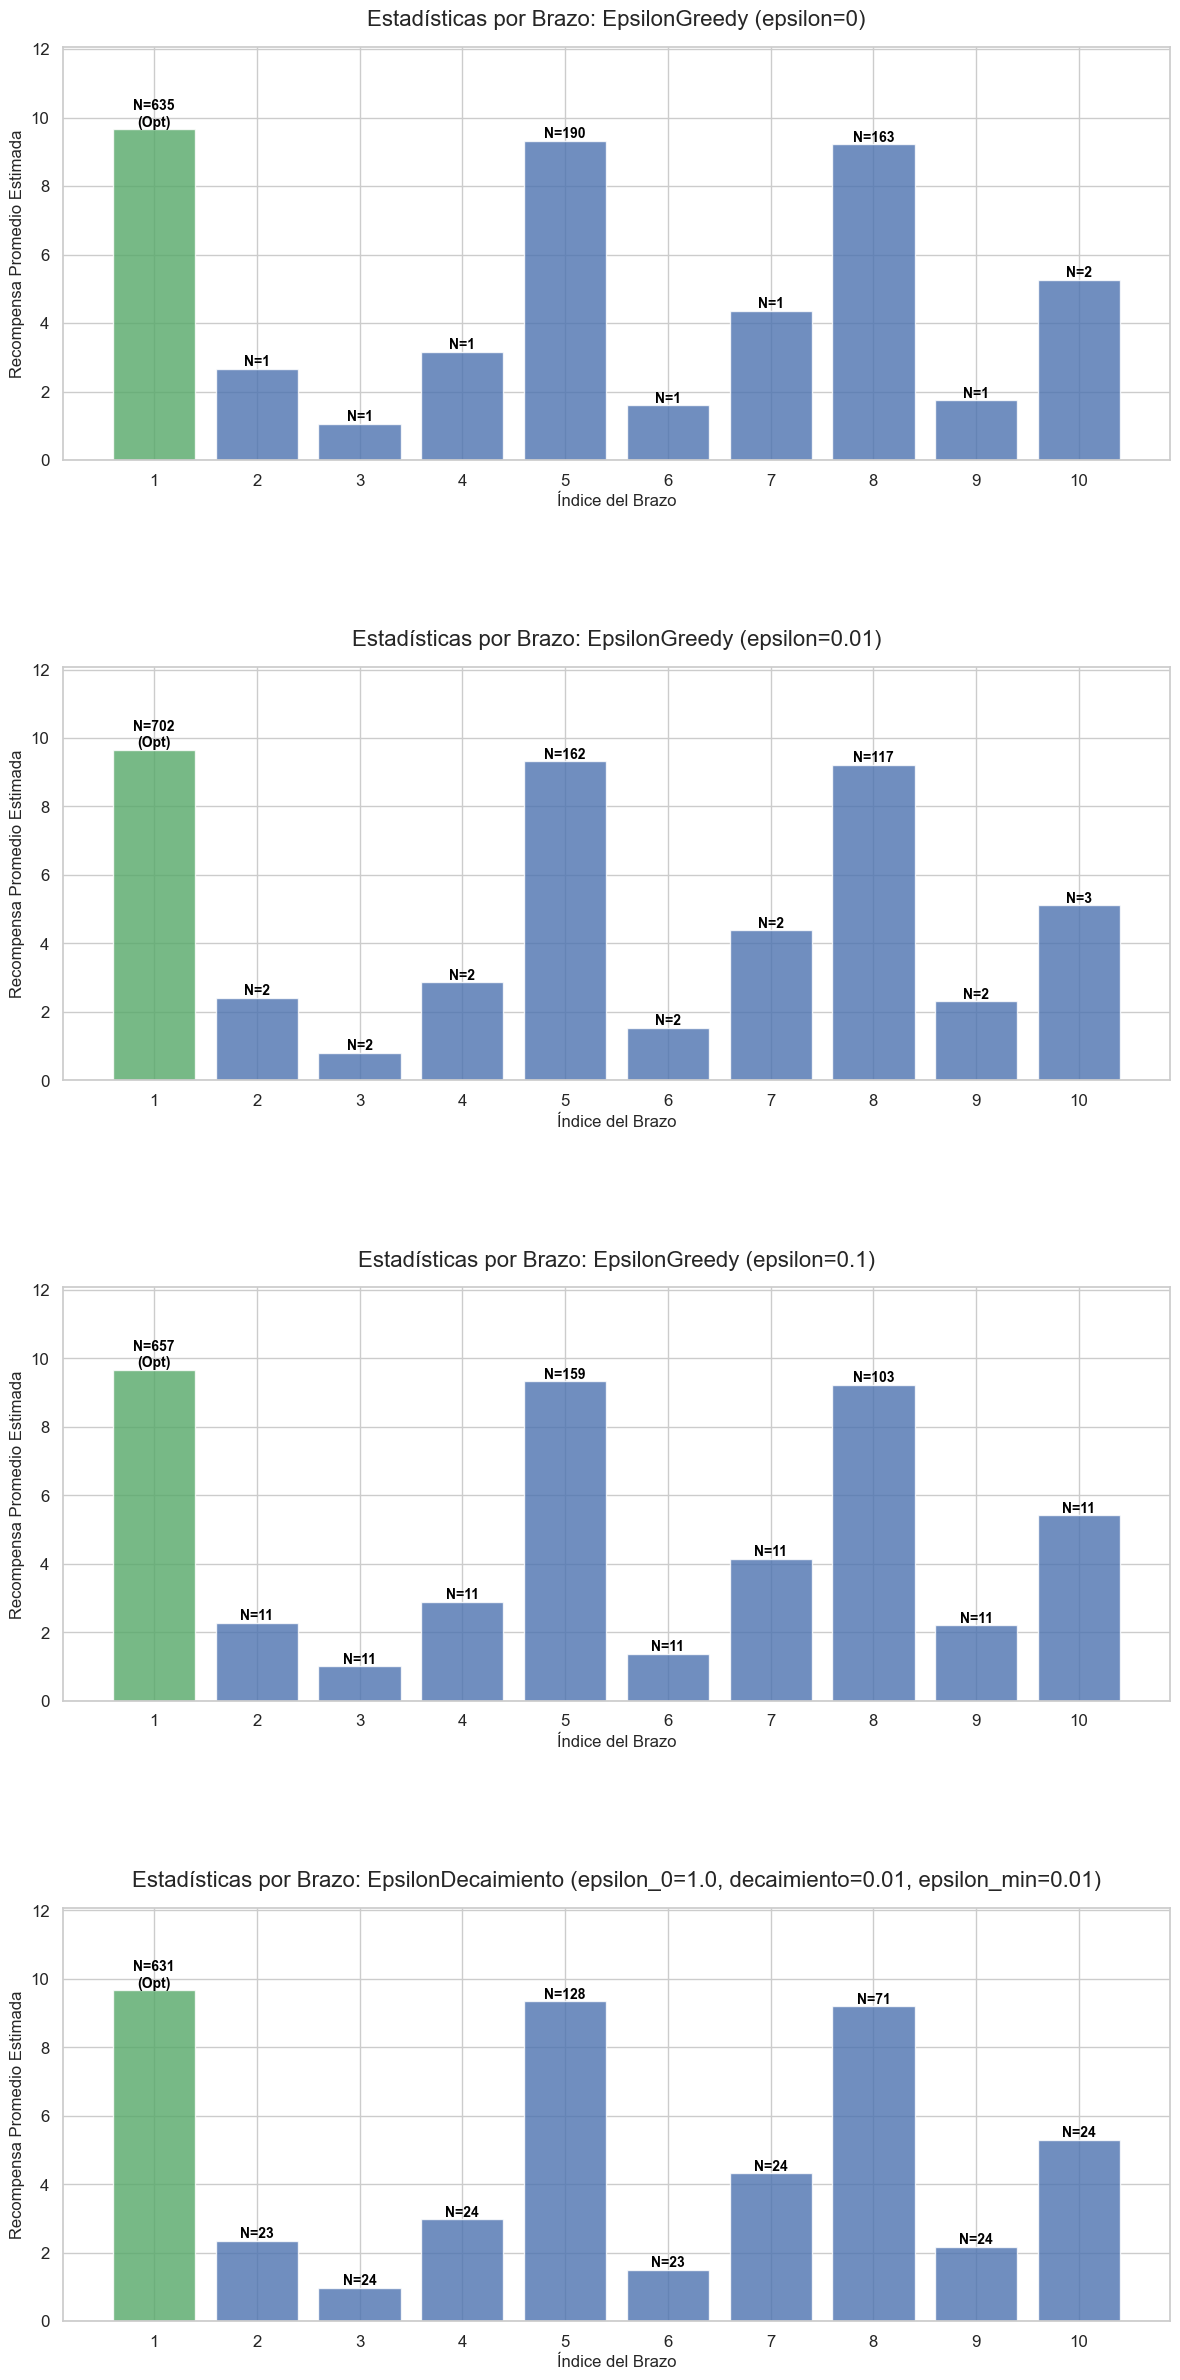

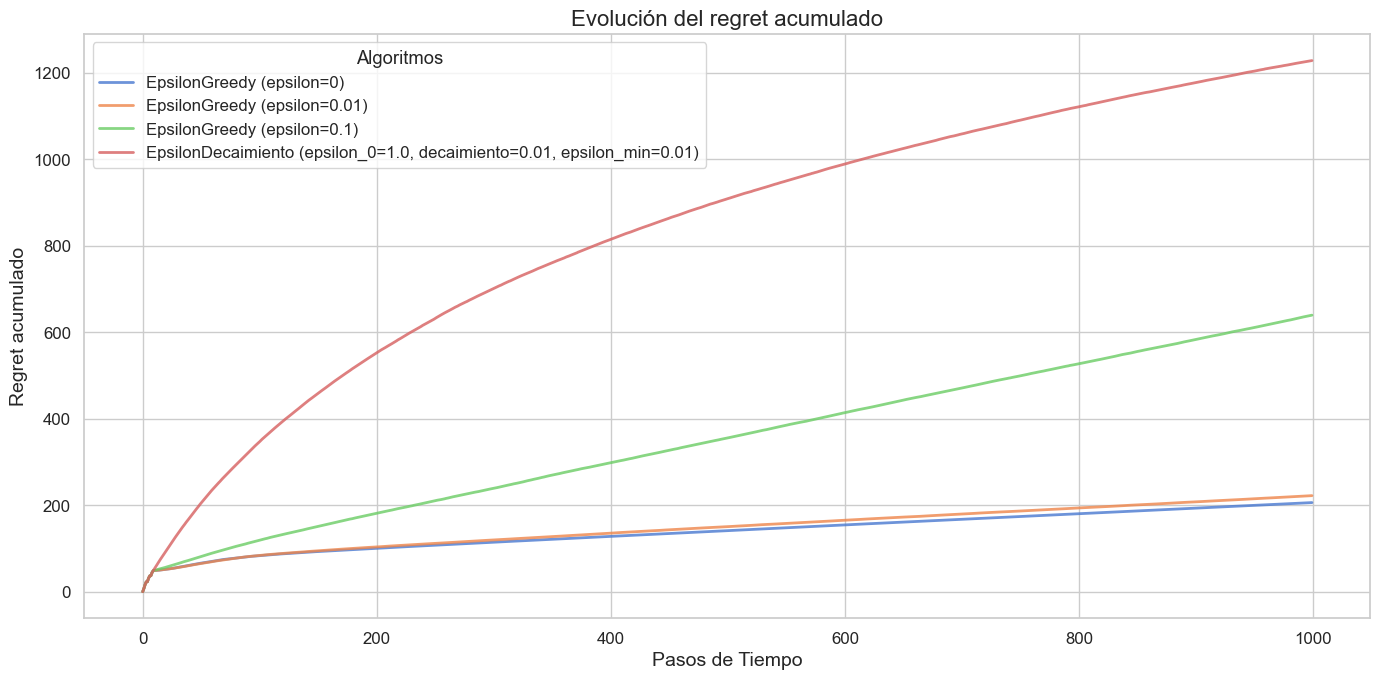

In [30]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis detallado de la imagen

Dado que se trata de una distribución de Bernoulli, cada brazo devuelve únicamente los valores 0 o 10 (debido al escalado), con probabilidad $p$. Esto introduce un alto nivel de ruido en las recompensas observadas, lo que dificulta la identificación del brazo óptimo, especialmente para los algoritmos con baja exploración ($\epsilon$ = 0 y $\epsilon$ = 0.01).

Este efecto se debe a que, tras la pasada inicial por todos los brazos, es frecuente que varios de ellos obtengan la misma recompensa inicial. En este caso, el algoritmo selecciona el brazo con el índice más bajo entre los empatados. Dicho brazo puede seguir proporcionando recompensas altas durante algunos pasos, pero en cuanto falla (devuelve 0), su media disminuye y el algoritmo pasa a otro brazo con una estimación similar. Sin embargo, debido a los empates frecuentes, no siempre se selecciona el brazo óptimo.

Además, si en una ejecución concreta el brazo óptimo falla en la fase inicial (devuelve 0), puede ocurrir que no vuelva a ser seleccionado durante toda la ejecución, siempre que exista al menos un brazo que haya obtenido una recompensa inicial mayor que cero (pues la media de ese brazo nunca será inferior a cero). Quitando ese caso, la media del brazo óptimo queda por debajo del resto en cuanto falle y no logra recuperarse hasta que las estimaciones se estabilizan, lo cual requiere un número elevado de pasos.

Como consecuencia, el desempeño global de los algoritmos es peor que en el caso de la distribución normal. No obstante, a medida que avanza el tiempo y se acumulan más observaciones, las medias de las recompensas se estabilizan y los algoritmos comienzan a seleccionar con mayor frecuencia el brazo óptimo.

En términos generales, las tres gráficas de líneas presentan un comportamiento similar al observado en la distribución normal, con algunas diferencias clave:

- La recompensa promedio parece más elevada debido a la naturaleza discreta de la distribución (cada acierto aporta una recompensa de 10).

- El valle inicial el porcentaje de selección del brazo óptimo se debe a los problemas de identificación del brazo óptimo al inicio (descritos en el párrafo anterior).

- El porcentaje de selección del brazo óptimo es menor en las primeras etapas, como consecuencia del elevado ruido y los empates iniciales.

- Este comportamiento se confirma en el histograma de estadísticas por brazo, donde se observa una menor concentración en el brazo óptimo, ya que parte de los brazos son elegidos de forma casi aleatoria durante las primeras fases debido a los empates en las estimaciones iniciales, y por la dificultad para identificar el brazo óptimo.


### Experimento 3: Distribución binomial

In [31]:
# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k, 10, scale=1)) # Generar un bandido con k brazos de distribución normal
print(bandit)  # Imprimir la configuración del bandido

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon y un algoritmo epsilon-decaimiento.
algorithms = [EpsilonGreedy(k=k, epsilon=0), EpsilonGreedy(k=k, epsilon=0.01), EpsilonGreedy(k=k, epsilon=0.1), EpsilonDecaimiento(k=k, epsilon_0=1.0, lambda_decay=0.01, epsilon_min=0.01), ]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmBinomial(n=10, p=0.55, scale=1), ArmBinomial(n=10, p=0.87, scale=1), ArmBinomial(n=10, p=0.57, scale=1), ArmBinomial(n=10, p=0.37, scale=1), ArmBinomial(n=10, p=0.41, scale=1), ArmBinomial(n=10, p=0.50, scale=1), ArmBinomial(n=10, p=0.45, scale=1), ArmBinomial(n=10, p=0.40, scale=1), ArmBinomial(n=10, p=0.13, scale=1), ArmBinomial(n=10, p=0.65, scale=1)
Optimal arm: 2 with expected reward=8.708


Al cambiar la distribución de recompensas de cada brazo a una distribución binomial con $n = 10$ y $p \in [0.1, 1.0]$, el brazo 2 resulta ser el óptimo, con una recompensa esperada de 8.708.

#### Visualización de los resultados

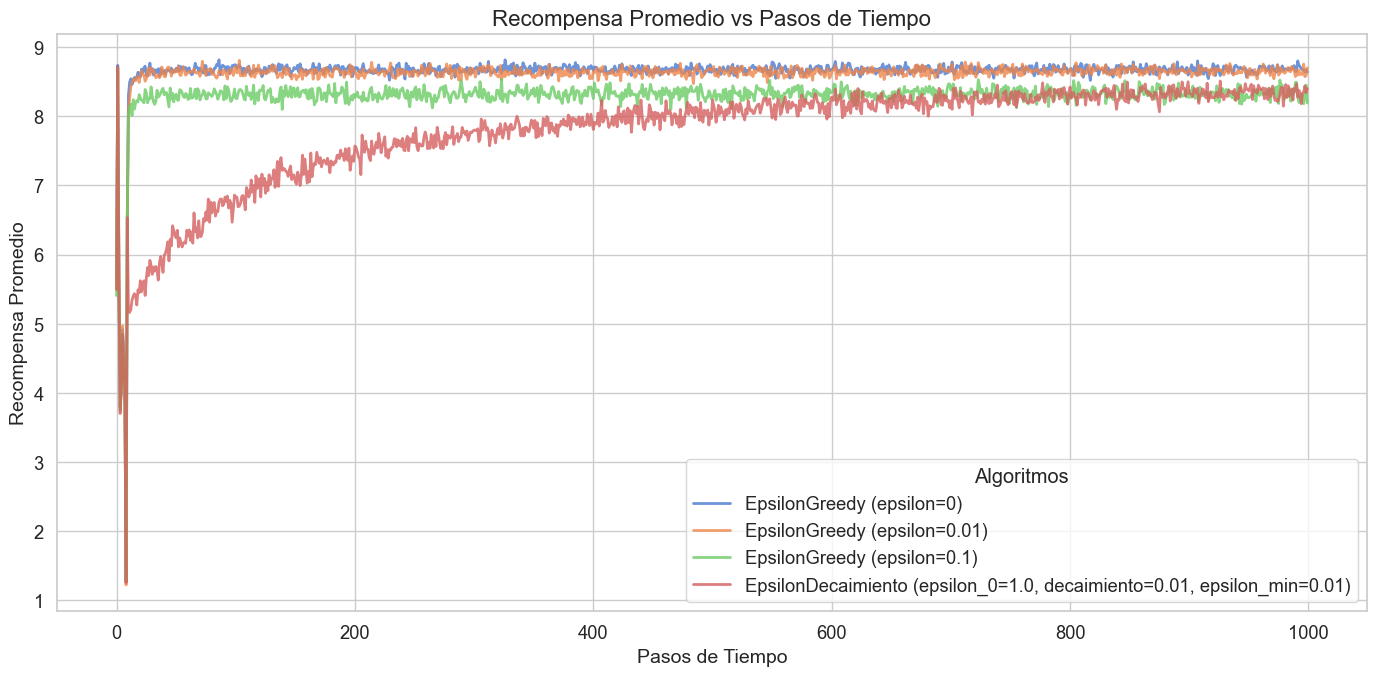

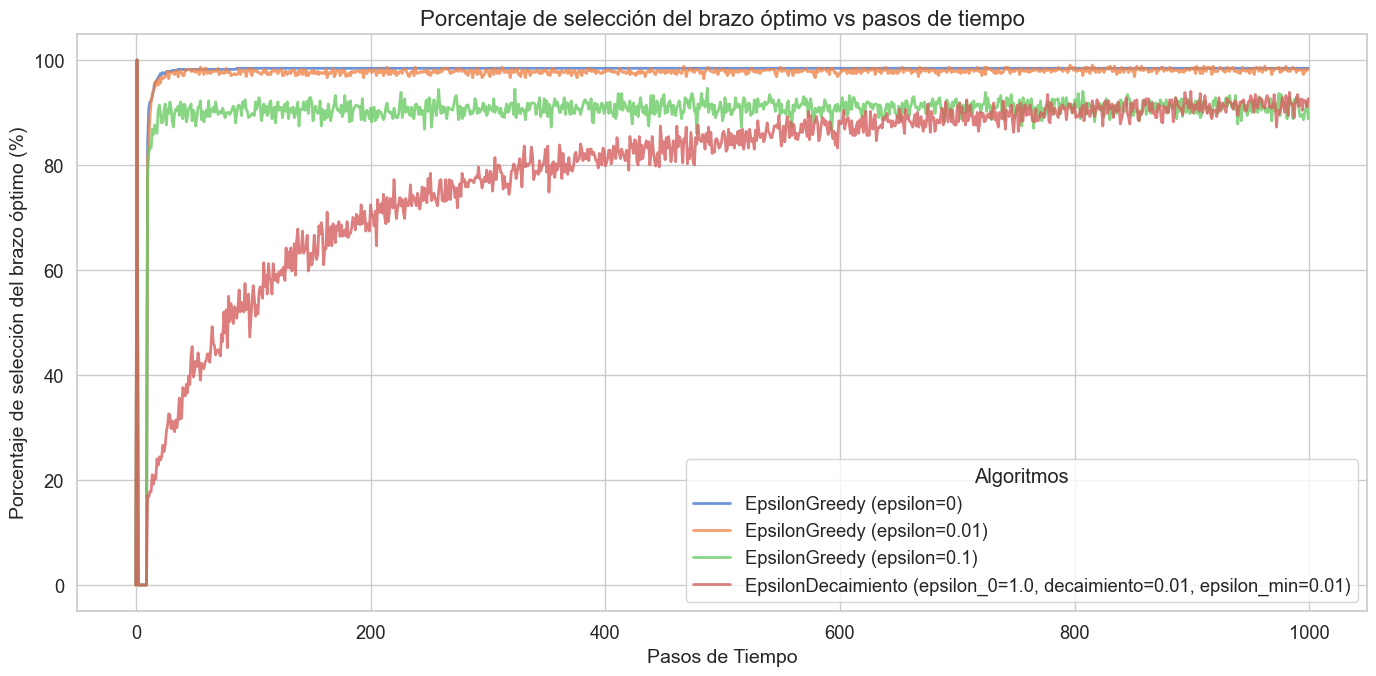

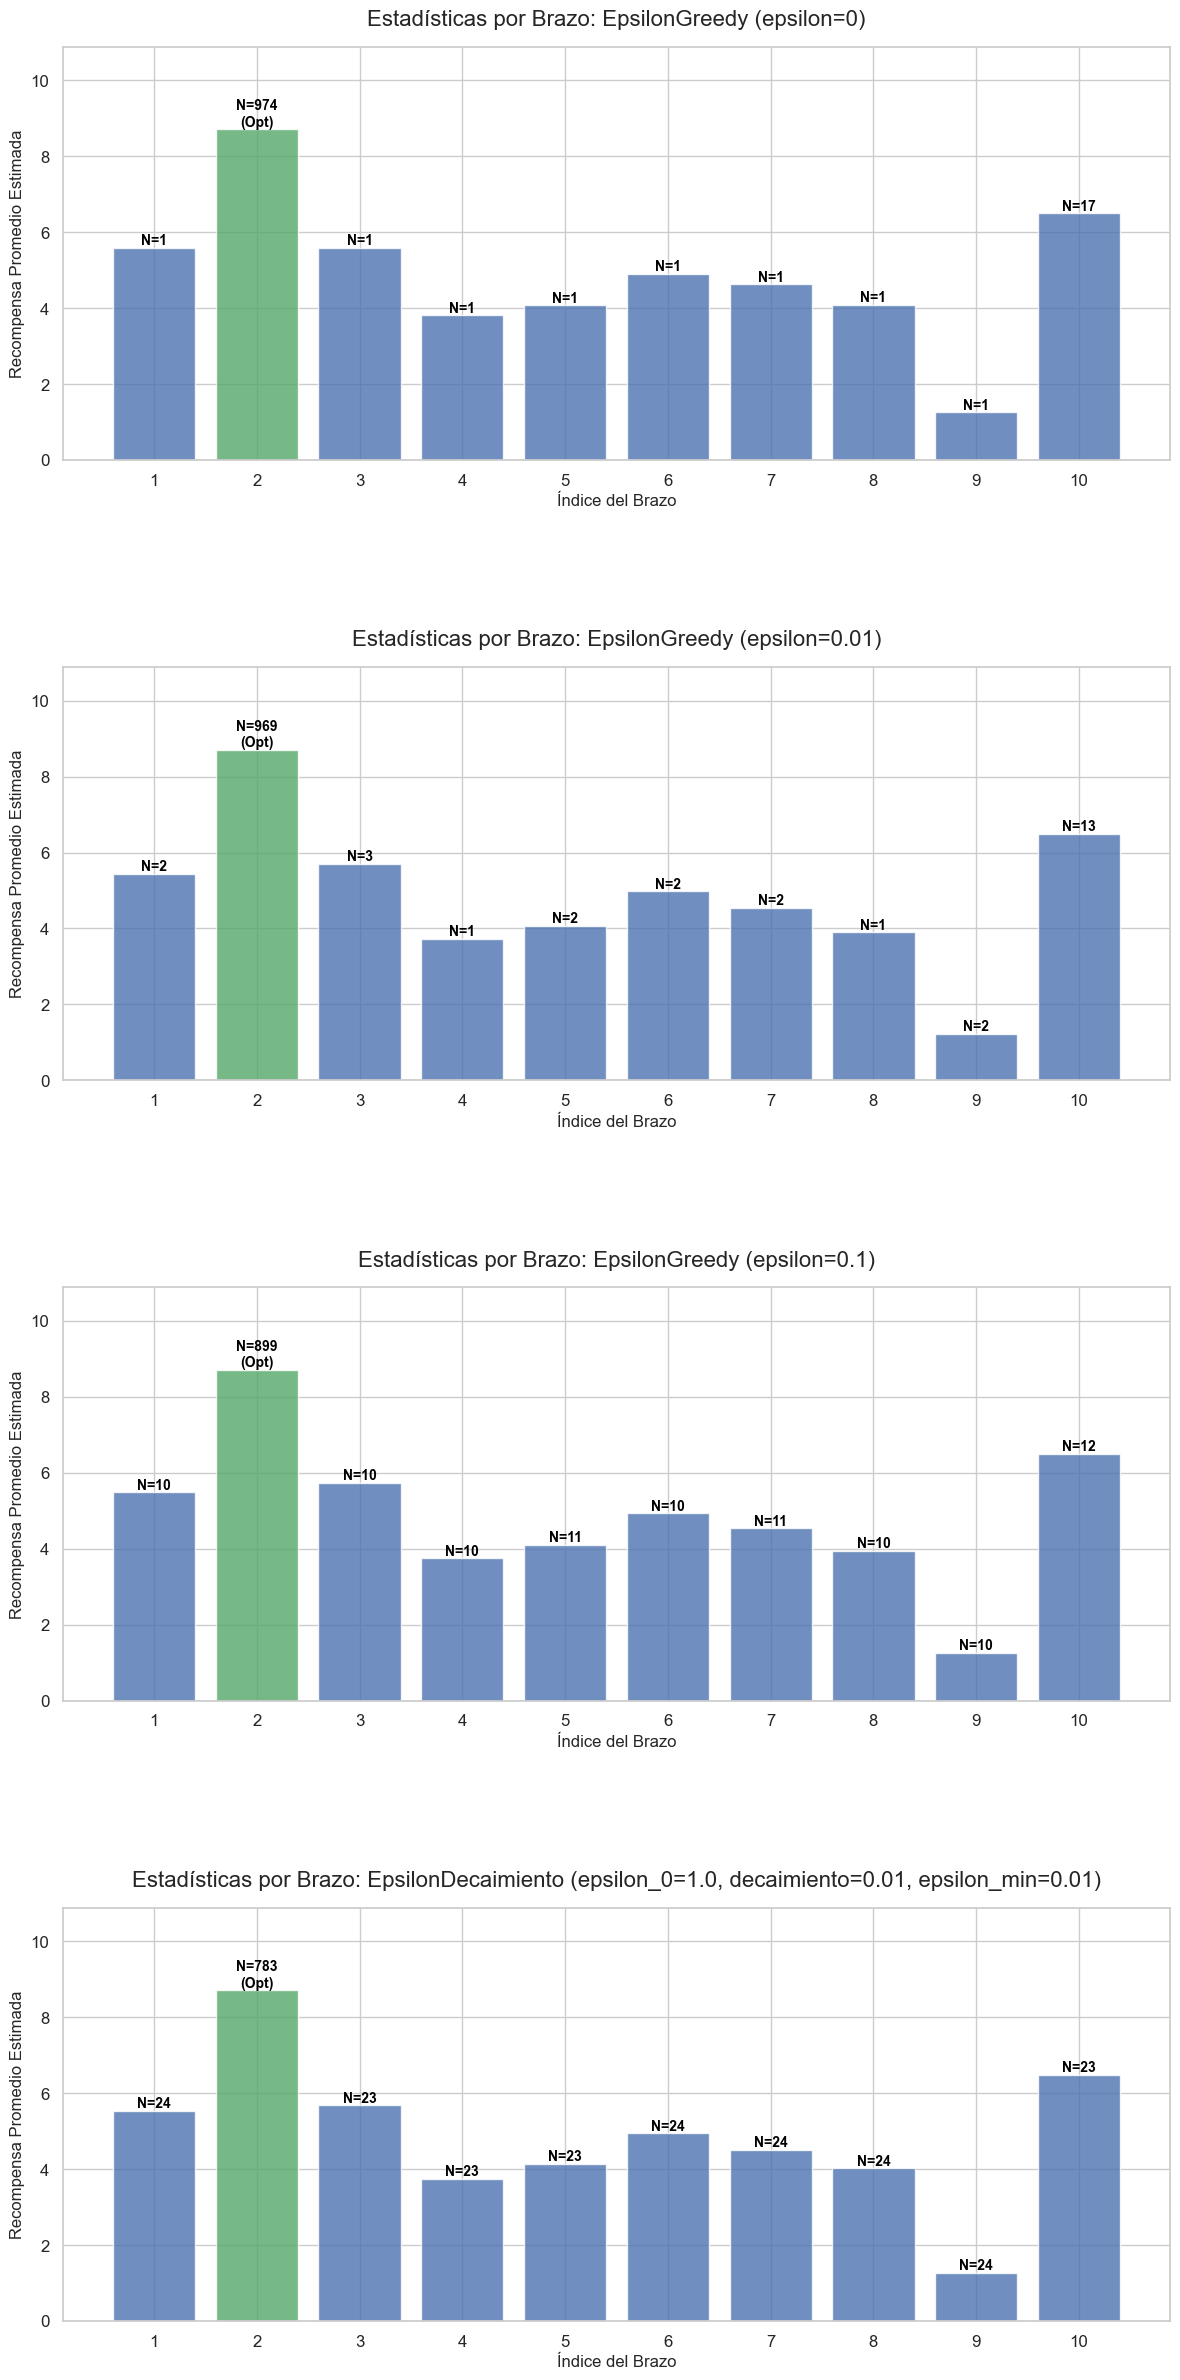

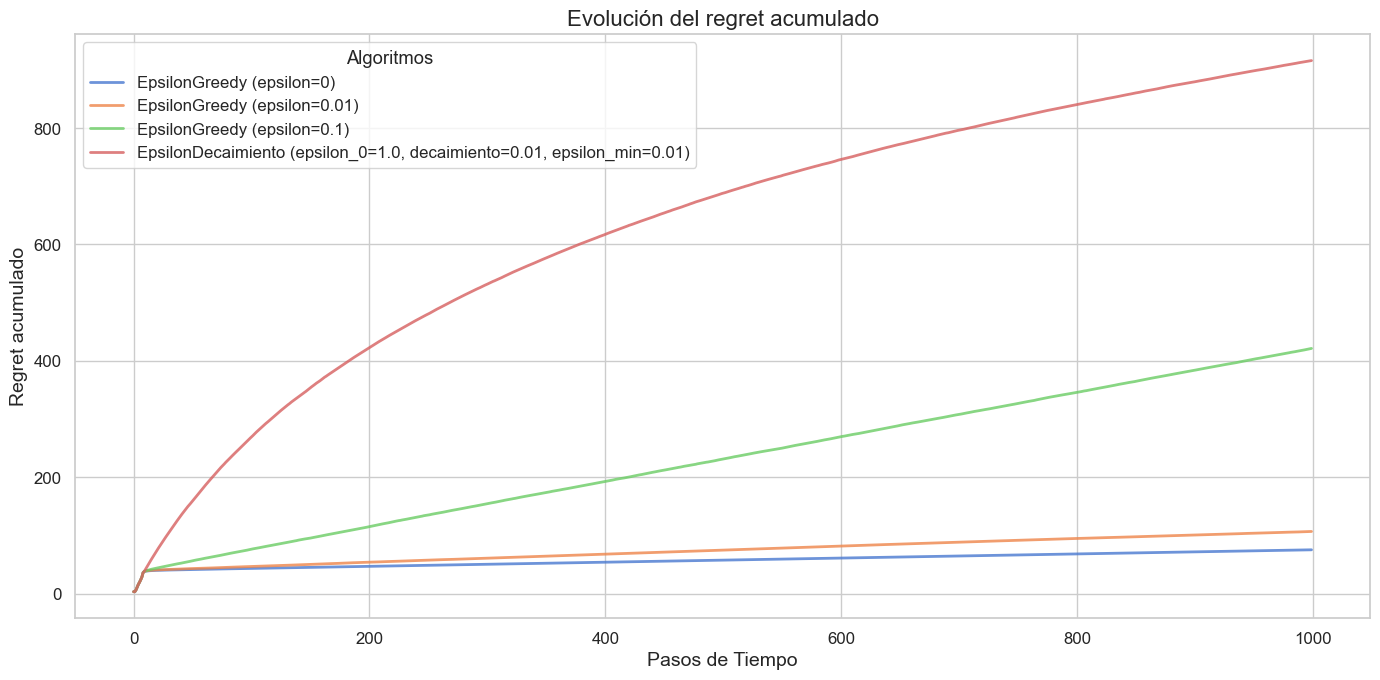

In [32]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis detallado de la imagen

En este caso, las conclusiones son muy similares a las obtenidas para la distribución normal. Al tratarse de una distribución binomial con $n=10$, cada brazo corresponde a la suma de 10 experimentos de Bernoulli independientes, lo que produce recompensas enteras entre 0 y 10. Esta agregación reduce significativamente la varianza respecto al caso Bernoulli, haciendo la distribución de recompensas más estable y menos ruidosa.

Como consecuencia, es menos probable que se produzcan empates en la estimación inicial de las recompensas y, en caso de que ocurran, las medias se estabilizan con mayor rapidez. Esto facilita la identificación del brazo óptimo desde etapas tempranas del proceso. Por ello, se observa que todos los algoritmos logran identificar correctamente el brazo óptimo conforme avanza el tiempo. Las conclusiones se presentan a continuación.




## Conclusiones

Hemos estudiado un **experimento de toma de decisiones secuenciales**, modelado mediante un **Multi-Armed Bandit (MAB)**, un problema fundamental en aprendizaje por refuerzo y teoría de la decisión. En este contexto, un agente debe aprender cuál es la mejor acción (brazo) a partir de la experiencia acumulada, enfrentándose al compromiso entre exploración y explotación. En este trabajo nos hemos centrado exclusivamente en el análisis del algoritmo **$\epsilon$-greedy** y su variante con **$\epsilon$-decaimiento**, extrayendo las siguientes conclusiones a partir de los resultados experimentales obtenidos en las tres distribuciones de recompensa estudiadas.

### **1. Exploración vs Explotación**

El algoritmo **$\epsilon$-Greedy** permite controlar explícitamente el equilibrio entre exploración y explotación:

* **Explotación pura ($\epsilon$ = 0):** Selecciona siempre el brazo con mejor recompensa estimada. En nuestro caso, su buen desempeño se debe a la exploración inicial forzada de todos los brazos, que permite obtener una estimación inicial razonable. No obstante, su rendimiento sigue dependiendo críticamente de dicha estimación: si esta es incorrecta, el algoritmo puede quedar atrapado en un brazo subóptimo durante toda la ejecución.
* **Exploración ($\epsilon$ > 0):** Introduce aleatoriedad en la selección de acciones, lo que permite corregir estimaciones erróneas y descubrir brazos mejores a lo largo del tiempo.

Los resultados muestran que:

* **$\epsilon$ = 0.1 (verde)** aprende más rápido en las primeras etapas gracias a su elevada exploración, especialmente en distribuciones menos ruidosas.
* **$\epsilon$ = 0.01 (naranja)** presenta una convergencia más lenta, pero logra mejores resultados a largo plazo al reducir la exploración innecesaria.
* **$\epsilon$ = 0 (azul)** puede obtener muy buenos resultados si la estimación inicial es acertada, pero presenta una alta varianza entre ejecuciones y un riesgo significativo de estancamiento, especialmente en distribuciones ruidosas como la Bernoulli.

### **2. Convergencia y comportamiento a largo plazo**

Los algoritmos con mayor exploración convergen más rápidamente hacia el brazo óptimo, ya que compensan la falta de información inicial. Sin embargo, mantener una exploración constante penaliza el rendimiento a largo plazo:

* **$\epsilon$ = 0.1** se estanca por debajo del óptimo debido a su exploración permanente.
* **$\epsilon$ = 0.01** alcanza una recompensa cercana al óptimo con suficiente número de pasos.
* **$\epsilon$-decaimiento** combina las ventajas de ambos enfoques: explora intensamente al inicio y reduce progresivamente la exploración, lo que le permite **superar a $\epsilon$ = 0.1 y alcanzar el mejor rendimiento a largo plazo** en todos los experimentos.

Este comportamiento se confirma tanto en la recompensa promedio como en el porcentaje de selección del brazo óptimo y en la evolución del regret acumulado.

### **3. Influencia de la distribución de recompensas**

El desempeño relativo de los algoritmos depende de forma clara de la **variabilidad de la distribución de recompensas**:

* En la **distribución normal**, todos los algoritmos identifican el brazo óptimo con relativa facilidad.
* En la **distribución de Bernoulli**, la alta varianza y los empates iniciales penalizan especialmente a los algoritmos con poca exploración, haciendo que $\epsilon$-decaimiento resulte claramente superior a largo plazo.
* En la **distribución binomial**, la menor varianza facilita la convergencia de todos los algoritmos.

Esto pone de manifiesto que **cuanto mayor es el ruido de las recompensas, más importante resulta mantener mecanismos de exploración**.

### **4. Aplicaciones y conclusiones finales**

* En problemas de toma de decisiones (ejemplo: recomendaciones, optimización de anuncios, medicina personalizada), una estrategia con **exploración adaptativa**, como **$\epsilon$-decaimiento**, resulta más robusta y eficiente.
* La ausencia total de exploración ($\epsilon$ = 0) solo es recomendable cuando se dispone de una buena estimación inicial o de conocimiento previo del entorno.
* Mantener una exploración constante elevada ($\epsilon$ grande) permite aprender rápido, pero penaliza el rendimiento a largo plazo.

En conclusión, los experimentos muestran que **el equilibrio entre exploración y explotación es clave**, y que el algoritmo **$\epsilon$-greedy con decaimiento** ofrece, junto al $\epsilon$-greedy con $\epsilon=0.01$ el mejor compromiso global en entornos con incertidumbre, maximizando la recompensa a largo plazo y minimizando el regret acumulado.